
# Instacart Market Basket Analysis

This notebook processes and analyzes the Instacart Market Basket Analysis dataset.

## Dataset

Kaggle source:

https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis

Expected files:

```text
data/
├── aisles.csv
├── departments.csv
├── order_products__prior.csv
├── order_products__train.csv
├── orders.csv
└── products.csv
Analysis objectives
Understand customer ordering behavior
Analyze purchase timing and reorder patterns
Identify popular products, aisles, and departments
Study products frequently purchased together
Create customer-level features
Export processed analytical datasets 


---------------------------------------------------------------------
Installation
---------------------------------------------------------------------


In [ ]:


Uncomment if required
!pip install pandas numpy matplotlib seaborn mlxtend



---------------------------------------------------------------------
Imports
---------------------------------------------------------------------


In [1]:

import os
import gc
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


Matplotlib created a temporary config/cache directory at /var/folders/53/sdyb1p3j4_7_mzk4t2x3r8c00000gq/T/matplotlib-newxtlom because the default path (/Users/redalpha04/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



---------------------------------------------------------------------
Configuration
---------------------------------------------------------------------


In [2]:

DATA_DIR = "data/instacart"
OUTPUT_DIR = "output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

required_files = [
    "aisles.csv",
    "departments.csv",
    "order_products__prior.csv",
    "order_products__train.csv",
    "orders.csv",
    "products.csv"
]

for filename in required_files:
    path = os.path.join(DATA_DIR, filename)
    print(filename, "OK" if os.path.exists(path) else "MISSING")


aisles.csv OK
departments.csv OK
order_products__prior.csv OK
order_products__train.csv OK
orders.csv OK
products.csv OK



---------------------------------------------------------------------
Load dimension tables
---------------------------------------------------------------------




Load product and order information
The prior order table is large, so it is loaded separately from the training order table.


In [3]:

aisles = pd.read_csv(
    os.path.join(DATA_DIR, "aisles.csv"),
    dtype={"aisle_id": "int32"}
)

departments = pd.read_csv(
    os.path.join(DATA_DIR, "departments.csv"),
    dtype={"department_id": "int32"}
)

products = pd.read_csv(
    os.path.join(DATA_DIR, "products.csv"),
    dtype={
        "product_id": "int32",
        "aisle_id": "int32",
        "department_id": "int32"
    }
)

orders = pd.read_csv(
    os.path.join(DATA_DIR, "orders.csv"),
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
        "days_since_prior_order": "float32"
    }
)

prior = pd.read_csv(
    os.path.join(DATA_DIR, "order_products__prior.csv"),
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8"
    }
)

train = pd.read_csv(
    os.path.join(DATA_DIR, "order_products__train.csv"),
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8"
    }
)

print("aisles:", aisles.shape)
print("departments:", departments.shape)
print("products:", products.shape)
print("orders:", orders.shape)
print("prior:", prior.shape)
print("train:", train.shape)


aisles: (134, 2)
departments: (21, 2)
products: (49688, 4)
orders: (3421083, 7)
prior: (32434489, 4)
train: (1384617, 4)



---------------------------------------------------------------------
Basic inspection
---------------------------------------------------------------------


In [5]:

tables = {
    "aisles": aisles,
    "departments": departments,
    "products": products,
    "orders": orders,
    "prior": prior,
    "train": train
}

for name, df in tables.items():
    print(f"{name.upper()}")
    display(df.head())
    print(df.dtypes)


AISLES


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


aisle_id     int32
aisle       object
dtype: object
DEPARTMENTS


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


department_id     int32
department       object
dtype: object
PRODUCTS


...

order_id                    int32
user_id                     int32
eval_set                   object
order_number                int16
order_dow                    int8
order_hour_of_day            int8
days_since_prior_order    float32
dtype: object
PRIOR


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


order_id             int32
product_id           int32
add_to_cart_order    int16
reordered             int8
dtype: object
TRAIN


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


order_id             int32
product_id           int32
add_to_cart_order    int16
reordered             int8
dtype: object


In [6]:

quality_summary = []

for name, df in tables.items():
    quality_summary.append({
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "missing_values": df.isna().sum().sum()
    })

quality_summary = pd.DataFrame(quality_summary)
quality_summary


,table,rows,columns,duplicate_rows,missing_values
0,aisles,134,2,0,0
1,departments,21,2,0,0
2,products,49688,4,0,0
3,orders,3421083,7,0,206209
4,prior,32434489,4,0,0
5,train,1384617,4,0,0



---------------------------------------------------------------------
Combine product dimensions
---------------------------------------------------------------------


In [7]:

products_enriched = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

products_enriched.head()


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry



---------------------------------------------------------------------
Order status overview
---------------------------------------------------------------------




Order dataset overview


In [8]:

orders_summary = pd.Series({
    "unique_users": orders["user_id"].nunique(),
    "unique_orders": orders["order_id"].nunique(),
    "average_orders_per_user": orders.groupby("user_id")["order_id"].nunique().mean(),
    "maximum_orders_for_one_user": orders.groupby("user_id")["order_number"].max().max(),
    "average_days_between_orders": orders["days_since_prior_order"].mean()
})

orders_summary


unique_users                   2.062090e+05
unique_orders                  3.421083e+06
average_orders_per_user        1.659037e+01
maximum_orders_for_one_user    1.000000e+02
average_days_between_orders    1.111483e+01
dtype: float64

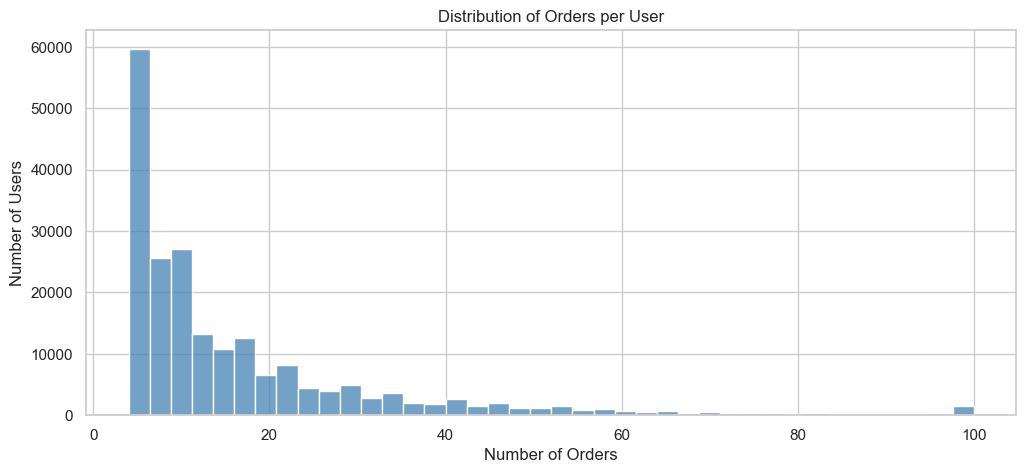

In [9]:

orders_per_user = (
    orders
    .groupby("user_id")["order_id"]
    .nunique()
    .reset_index(name="number_of_orders")
)

plt.figure(figsize=(12, 5))

sns.histplot(
    orders_per_user["number_of_orders"],
    bins=40,
    kde=False,
    color="steelblue"
)

plt.title("Distribution of Orders per User")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Users")
plt.show()



---------------------------------------------------------------------
Day and hour analysis
---------------------------------------------------------------------


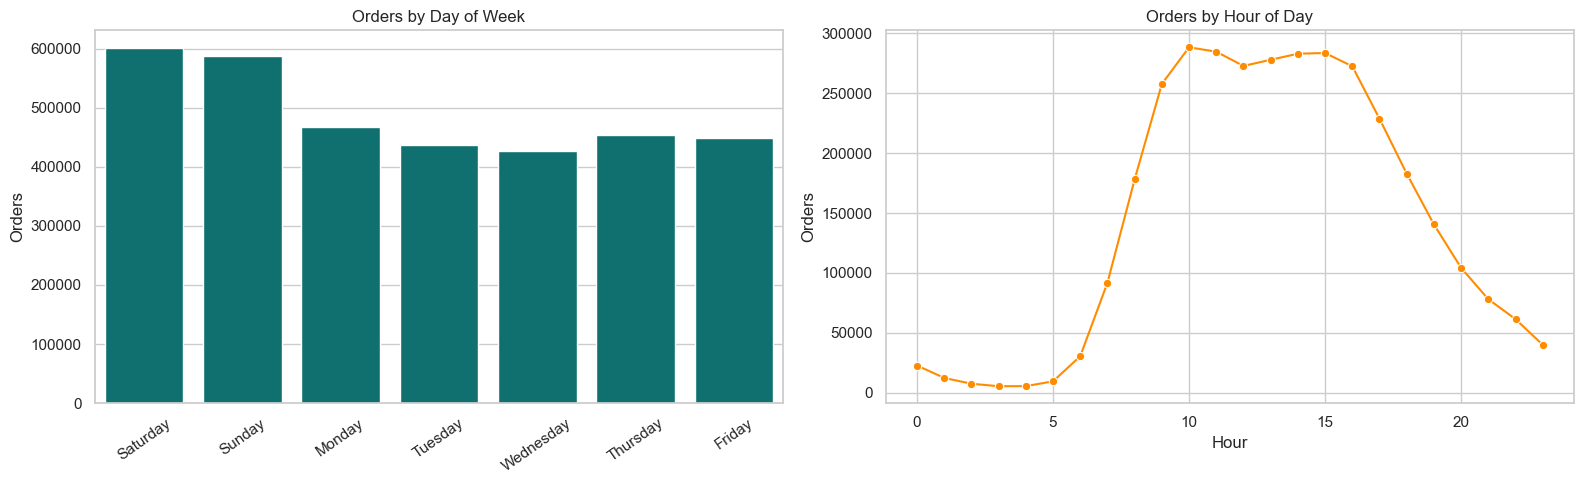

In [10]:

day_names = {
    0: "Saturday",
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday"
}

orders["order_day"] = orders["order_dow"].map(day_names)

orders_by_day = (
    orders["order_day"]
    .value_counts()
    .reindex(day_names.values())
    .reset_index()
)

orders_by_day.columns = ["order_day", "orders"]

orders_by_hour = (
    orders["order_hour_of_day"]
    .value_counts()
    .sort_index()
    .reset_index()
)

orders_by_hour.columns = ["hour", "orders"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=orders_by_day,
    x="order_day",
    y="orders",
    ax=axes[0],
    color="teal"
)

axes[0].set_title("Orders by Day of Week")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_xlabel("")
axes[0].set_ylabel("Orders")

sns.lineplot(
    data=orders_by_hour,
    x="hour",
    y="orders",
    marker="o",
    ax=axes[1],
    color="darkorange"
)

axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()



---------------------------------------------------------------------
Merge prior products with product details
---------------------------------------------------------------------




Product and department analysis


In [11]:

prior_products = prior.merge(
    products_enriched,
    on="product_id",
    how="left"
)

train_products = train.merge(
    products_enriched,
    on="product_id",
    how="left"
)

prior_products.head()


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


In [12]:

top_products = (
    prior_products
    .groupby(["product_id", "product_name"], as_index=False)
    .agg(
        purchases=("order_id", "count"),
        unique_users=("order_id", "nunique"),
        reorder_rate=("reordered", "mean")
    )
    .sort_values("purchases", ascending=False)
    .head(20)
)

top_products


,product_id,product_name,purchases,unique_users,reorder_rate
24848,24852,Banana,472565,472565,0.843501
13172,13176,Bag of Organic Bananas,379450,379450,0.832555
21133,21137,Organic Strawberries,264683,264683,0.777704
21899,21903,Organic Baby Spinach,241921,241921,0.772500
47198,47209,Organic Hass Avocado,213584,213584,0.796553
47755,47766,Organic Avocado,176815,176815,0.758103
47615,47626,Large Lemon,152657,152657,0.696038
16793,16797,Strawberries,142951,142951,0.698155
26204,26209,Limes,140627,140627,0.681007
27839,27845,Organic Whole Milk,137905,137905,0.830354


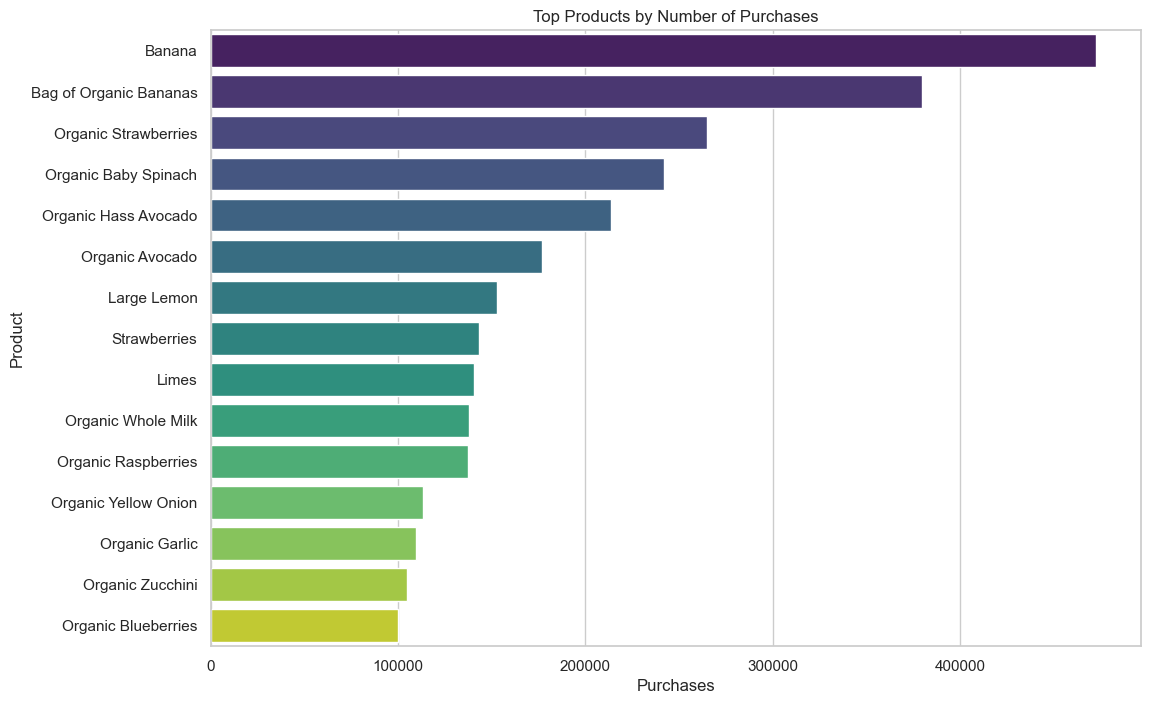

In [13]:

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_products.head(15),
    x="purchases",
    y="product_name",
    palette="viridis"
)

plt.title("Top Products by Number of Purchases")
plt.xlabel("Purchases")
plt.ylabel("Product")
plt.show()


In [14]:

department_analysis = (
    prior_products
    .groupby("department", as_index=False)
    .agg(
        purchases=("product_id", "count"),
        unique_products=("product_id", "nunique"),
        reorder_rate=("reordered", "mean")
    )
    .sort_values("purchases", ascending=False)
)

department_analysis


,department,purchases,unique_products,reorder_rate
19,produce,9479291,1684,0.649913
7,dairy eggs,5414016,3448,0.669969
20,snacks,2887550,6263,0.574180
3,beverages,2690129,4363,0.653460
10,frozen,2236432,4007,0.541885
16,pantry,1875577,5370,0.346721
2,bakery,1176787,1516,0.628141
6,canned goods,1068058,2092,0.457405
8,deli,1051249,1322,0.607719
9,dry goods pasta,866627,1858,0.461076


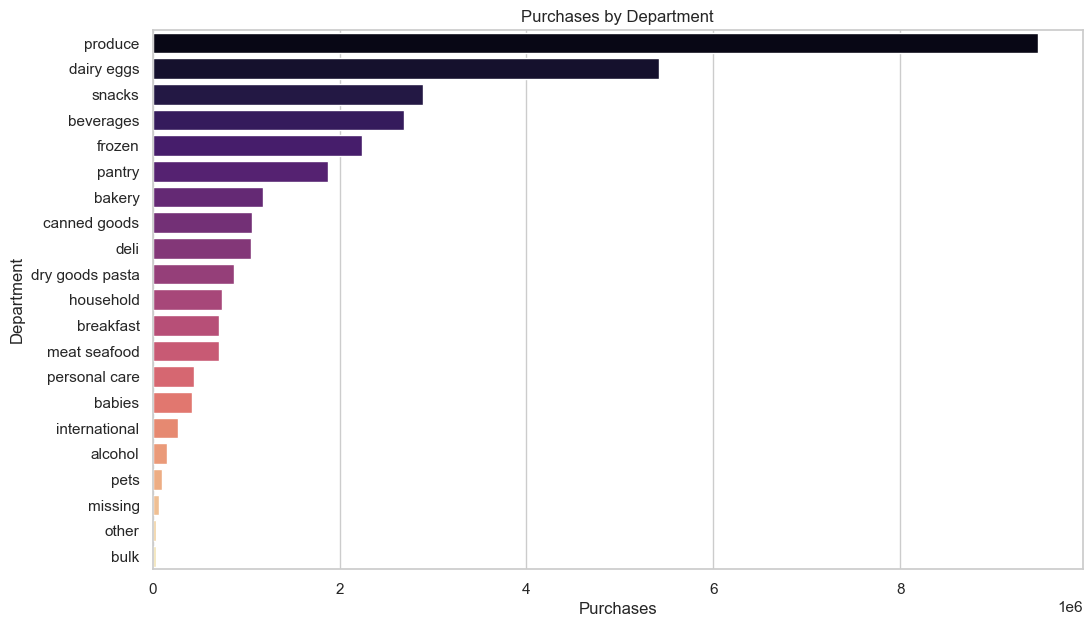

In [15]:

plt.figure(figsize=(12, 7))

sns.barplot(
    data=department_analysis,
    x="purchases",
    y="department",
    palette="magma"
)

plt.title("Purchases by Department")
plt.xlabel("Purchases")
plt.ylabel("Department")
plt.show()


In [16]:

aisle_analysis = (
    prior_products
    .groupby("aisle", as_index=False)
    .agg(
        purchases=("product_id", "count"),
        unique_products=("product_id", "nunique"),
        reorder_rate=("reordered", "mean")
    )
    .sort_values("purchases", ascending=False)
)

aisle_analysis.head(20)


,aisle,purchases,unique_products,reorder_rate
50,fresh fruits,3642188,382,0.718104
53,fresh vegetables,3418021,569,0.594546
98,packaged vegetables fruits,1765313,615,0.638514
133,yogurt,1452343,1026,0.686489
93,packaged cheese,979763,890,0.585226
83,milk,891015,243,0.781428
131,water seltzer sparkling water,841533,344,0.729593
25,chips pretzels,722470,989,0.588795
119,soy lactosefree,638253,293,0.692551
11,bread,584834,557,0.670168



---------------------------------------------------------------------
Reorder analysis
---------------------------------------------------------------------




Reorder behavior
The reordered column indicates whether a product had been purchased previously by the same customer.


In [17]:

reorder_summary = pd.Series({
    "first_time_purchases": (prior["reordered"] == 0).sum(),
    "reordered_purchases": (prior["reordered"] == 1).sum(),
    "overall_reorder_rate": prior["reordered"].mean()
})

reorder_summary


first_time_purchases    1.330795e+07
reordered_purchases     1.912654e+07
overall_reorder_rate    5.896975e-01
dtype: float64

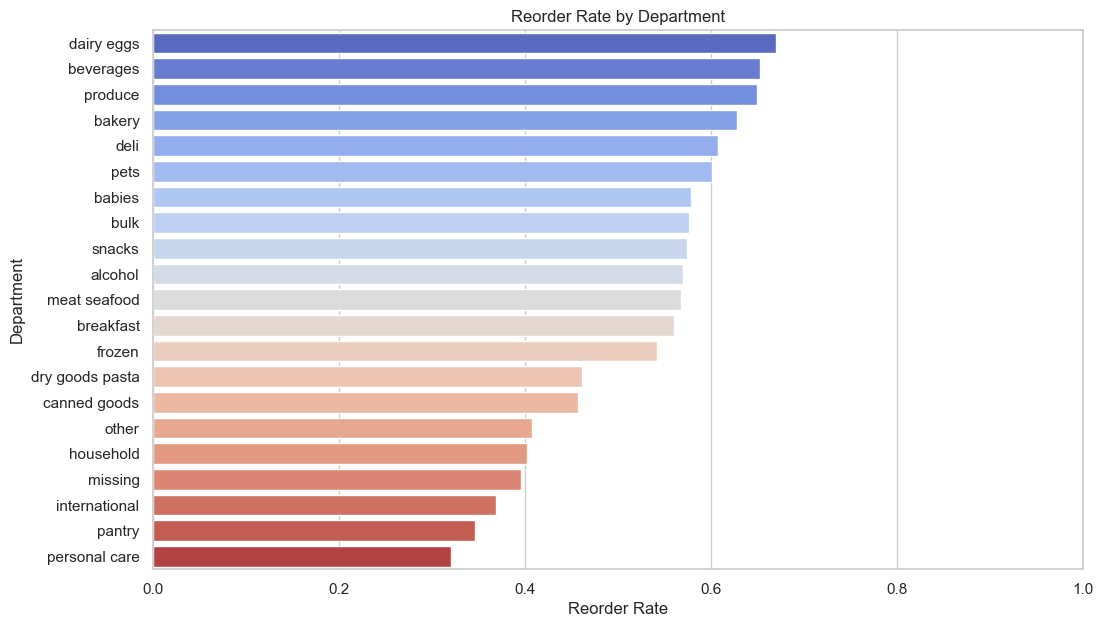

In [18]:

reorder_by_department = (
    prior_products
    .groupby("department", as_index=False)
    .agg(
        purchases=("product_id", "count"),
        reorder_rate=("reordered", "mean")
    )
    .sort_values("reorder_rate", ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=reorder_by_department,
    x="reorder_rate",
    y="department",
    palette="coolwarm"
)

plt.title("Reorder Rate by Department")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.xlim(0, 1)
plt.show()


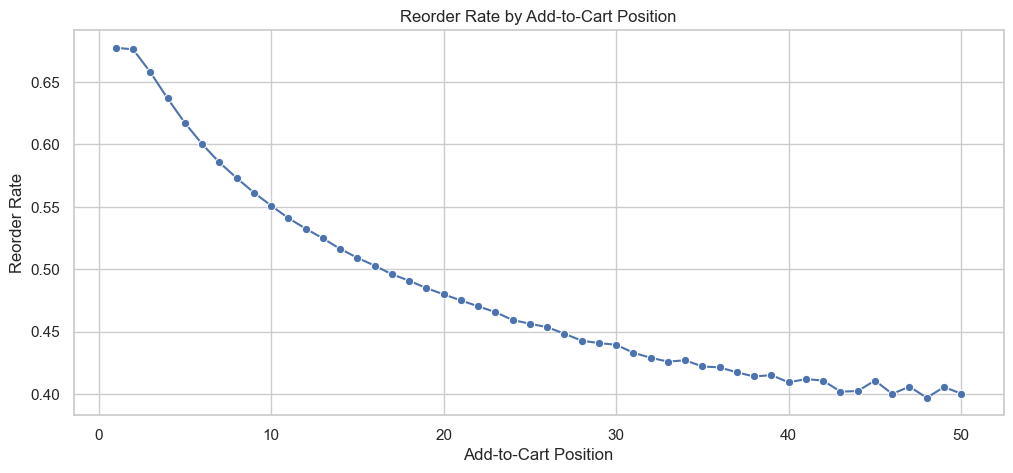

In [19]:

reorder_by_cart_position = (
    prior
    .groupby("add_to_cart_order", as_index=False)
    .agg(
        products=("product_id", "count"),
        reorder_rate=("reordered", "mean")
    )
)

reorder_by_cart_position = reorder_by_cart_position[
    reorder_by_cart_position["add_to_cart_order"] <= 50
]

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=reorder_by_cart_position,
    x="add_to_cart_order",
    y="reorder_rate",
    marker="o"
)

plt.title("Reorder Rate by Add-to-Cart Position")
plt.xlabel("Add-to-Cart Position")
plt.ylabel("Reorder Rate")
plt.show()



---------------------------------------------------------------------
Basket size
---------------------------------------------------------------------




Basket-size analysis


In [20]:

basket_size = (
    prior
    .groupby("order_id")
    .size()
    .reset_index(name="items_in_order")
)

basket_summary = basket_size["items_in_order"].describe()
basket_summary


count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: items_in_order, dtype: float64

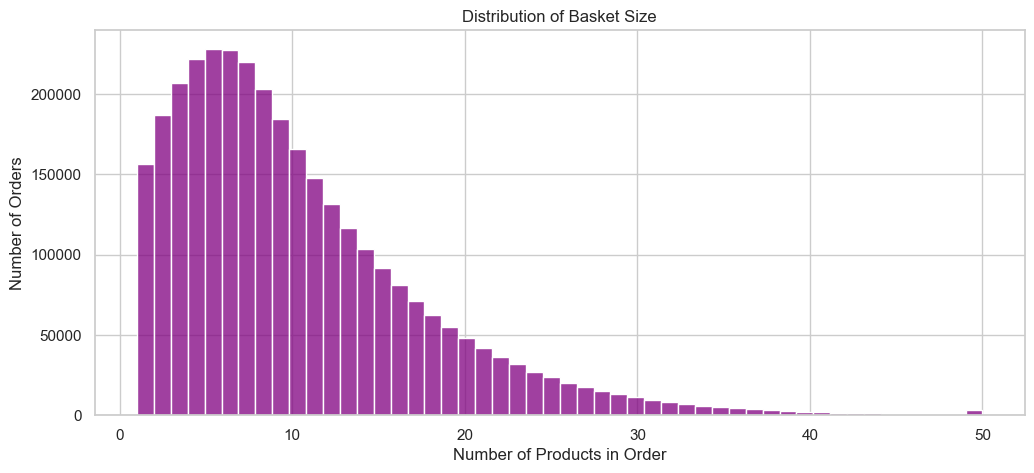

In [21]:

plt.figure(figsize=(12, 5))

sns.histplot(
    basket_size["items_in_order"].clip(upper=50),
    bins=50,
    color="purple"
)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Products in Order")
plt.ylabel("Number of Orders")
plt.show()



---------------------------------------------------------------------
User features
---------------------------------------------------------------------




Customer-level features
The following features can be used for segmentation or machine-learning tasks:

Number of orders
Total products purchased
Average basket size
Average reorder rate
Average interval between orders 

In [22]:

user_order_features = (
    orders
    .groupby("user_id", as_index=False)
    .agg(
        number_of_orders=("order_id", "nunique"),
        average_days_between_orders=("days_since_prior_order", "mean"),
        average_order_hour=("order_hour_of_day", "mean"),
        average_order_day=("order_dow", "mean")
    )
)

user_product_features = (
    prior
    .merge(orders[["order_id", "user_id"]], on="order_id", how="left")
    .groupby("user_id", as_index=False)
    .agg(
        total_products_purchased=("product_id", "count"),
        unique_products_purchased=("product_id", "nunique"),
        average_reorder_rate=("reordered", "mean"),
        average_cart_position=("add_to_cart_order", "mean")
    )
)

user_features = user_order_features.merge(
    user_product_features,
    on="user_id",
    how="left"
)

user_features.head()


,user_id,number_of_orders,average_days_between_orders,average_order_hour,average_order_day,total_products_purchased,unique_products_purchased,average_reorder_rate,average_cart_position
0,1,11,19.000000,10.090909,2.636364,59,18,0.694915,3.627119
1,2,15,16.285715,10.600000,2.066667,195,102,0.476923,8.553846
2,3,13,12.000000,16.307692,1.384615,88,33,0.625000,4.443182
3,4,6,17.000000,12.500000,4.500000,18,17,0.055556,2.777778
4,5,5,11.500000,15.000000,1.400000,37,23,0.378378,5.513514



---------------------------------------------------------------------
Market basket analysis
---------------------------------------------------------------------




Market-basket analysis
The following section identifies frequently purchased product pairs.

To keep the computation manageable, it uses:

The most frequently purchased products
Orders containing at least two selected products
A limited number of products for pair generation 

In [30]:

TOP_N_PRODUCTS_FOR_PAIRS = 100

popular_product_ids = (
    prior["product_id"]
    .value_counts()
    .head(TOP_N_PRODUCTS_FOR_PAIRS)
    .index
)

basket_pairs_data = prior[
    prior["product_id"].isin(popular_product_ids)
][["order_id", "product_id"]].drop_duplicates()

basket_product_lists = (
    basket_pairs_data
    .groupby("order_id")["product_id"]
    .apply(list)
)

pair_counts = {}

for product_list in basket_product_lists:
    if len(product_list) < 2:
        continue

    for product_a, product_b in combinations(sorted(product_list), 2):
        pair = (product_a, product_b)
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

pair_counts_df = pd.DataFrame(
    [
        {
            "product_id_a": pair[0],
            "product_id_b": pair[1],
            "pair_orders": count
        }
        for pair, count in pair_counts.items()
    ]
)

pair_counts_df = pair_counts_df.sort_values(
    "pair_orders",
    ascending=False
)

pair_counts_df.head()


,product_id_a,product_id_b,pair_orders
6,13176,47209,62341
512,13176,21137,61628
16,21137,24852,56156
23,24852,47766,53395
50,21903,24852,51395


In [31]:

pair_counts_df = (
    pair_counts_df
    .merge(
        products[["product_id", "product_name"]]
        .rename(columns={
            "product_id": "product_id_a",
            "product_name": "product_name_a"
        }),
        on="product_id_a",
        how="left"
    )
    .merge(
        products[["product_id", "product_name"]]
        .rename(columns={
            "product_id": "product_id_b",
            "product_name": "product_name_b"
        }),
        on="product_id_b",
        how="left"
    )
)

pair_counts_df.head(20)


,product_id_a,product_id_b,pair_orders,product_name_a,product_name_b
0,13176,47209,62341,Bag of Organic Bananas,Organic Hass Avocado
1,13176,21137,61628,Bag of Organic Bananas,Organic Strawberries
2,21137,24852,56156,Organic Strawberries,Banana
3,24852,47766,53395,Banana,Organic Avocado
4,21903,24852,51395,Organic Baby Spinach,Banana
5,13176,21903,50372,Bag of Organic Bananas,Organic Baby Spinach
6,16797,24852,41232,Strawberries,Banana
7,24852,47626,40880,Banana,Large Lemon
8,21137,47209,40794,Organic Strawberries,Organic Hass Avocado
9,13176,27966,40503,Bag of Organic Bananas,Organic Raspberries



---------------------------------------------------------------------
Train set validation
---------------------------------------------------------------------




Train-set validation
The training set contains the products in a user's next order. It can be used to evaluate recommendation or reorder-prediction models.


In [27]:

train_order_counts = (
    train
    .groupby("order_id")
    .size()
    .reset_index(name="train_items")
)

train_order_counts.describe()


,order_id,train_items
count,1.312090e+05,131209.000000
mean,1.704050e+06,10.552759
std,9.889077e+05,7.932847
min,1.000000e+00,1.000000
25%,8.451640e+05,5.000000
50%,1.696847e+06,9.000000
75%,2.561480e+06,14.000000
max,3.421070e+06,80.000000


In [28]:

train_reorder_summary = (
    train["reordered"]
    .value_counts(normalize=True)
    .sort_index()
    .rename(index={
        0: "first-time purchase",
        1: "reordered purchase"
    })
    .mul(100)
    .round(2)
)

train_reorder_summary


first-time purchase    40.14
reordered purchase     59.86
Name: reordered, dtype: float64


---------------------------------------------------------------------
Export
---------------------------------------------------------------------




Export processed datasets


In [ ]:

products_enriched.to_csv(
    os.path.join(OUTPUT_DIR, "products_enriched.csv"),
    index=False
)

department_analysis.to_csv(
    os.path.join(OUTPUT_DIR, "department_analysis.csv"),
    index=False
)

aisle_analysis.to_csv(
    os.path.join(OUTPUT_DIR, "aisle_analysis.csv"),
    index=False
)

top_products.to_csv(
    os.path.join(OUTPUT_DIR, "top_products.csv"),
    index=False
)

user_features.to_csv(
    os.path.join(OUTPUT_DIR, "user_features.csv"),
    index=False
)

pair_counts_df.to_csv(
    os.path.join(OUTPUT_DIR, "frequent_product_pairs.csv"),
    index=False
)

basket_size.to_csv(
    os.path.join(OUTPUT_DIR, "basket_size.csv"),
    index=False
)

print(f"Processed files exported to: {OUTPUT_DIR}")



---------------------------------------------------------------------
Optional modeling ideas
---------------------------------------------------------------------




Possible next steps
This processed data can support several machine-learning projects:

Next-product recommendation

Predict which product a user will buy next.
Reorder prediction

Predict whether a product will be reordered.
Customer segmentation

Cluster customers using user_features.
Market-basket recommendation

Recommend products based on frequently purchased product pairs.
Time-based demand analysis

Forecast product demand by day or hour.
Association-rule mining

Use support, confidence, and lift to generate product recommendations. 